# Feynman Equations — Multivariate Amplitude Encoding with QFun

This notebook demonstrates **multivariate quantum amplitude encoding** using the
27 Feynman physics equations from the KAN benchmark (arXiv:2404.19756).

**Key idea:** For a $d$-variable function $f(x_1,\ldots,x_d)$, allocate $n_k$
qubits per variable.  Each variable is discretised to $2^{n_k}$ points, giving
a total grid of $2^{n_1+\cdots+n_d}$ points encoded into $n_1+\cdots+n_d$ qubits.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import qfun
from qfun.feynman_dataset import list_equations, get_equation

print(f"QFun loaded — {len(list_equations())} Feynman equations available")

QFun loaded — 27 Feynman equations available


## 1  Dataset Overview

Each `FeynmanEquation` stores an ID, human-readable formula, variable names,
default domains, and a callable Python function.

In [2]:
equations = list_equations()

print(f"{'ID':<12} {'#Vars':>5}  {'Formula'}")
print("-" * 60)
for eq in equations:
    print(f"{eq.eq_id:<12} {len(eq.variables):>5}  {eq.formula}")

ID           #Vars  Formula
------------------------------------------------------------
I.6.2            2  exp(-θ²/(2σ²)) / √(2πσ²)
I.6.2b           3  exp(-(θ-θ₁)²/(2σ²)) / √(2πσ²)
I.9.18           6  (a-c)² + (b-d)² + (e-f)²
I.12.11          2  1 + a·sin(θ)
I.13.12          2  a·(1/b − 1)
I.15.3x          2  a / √(1 − b²)
I.16.6           2  (a + b) / (1 + a·b)
I.18.4           2  (1 + a·b) / (1 + a)
I.26.2           2  arcsin(n·sin(θ₂))
I.27.6           2  1 / (1/a + 1/b)
I.29.16          3  √(1 + a² − 2a·cos(θ₁ − θ₂))
I.30.3           2  sin²(a·b/2) / sin²(b/2)
I.30.5           2  arcsin(a/b)
I.37.4           2  1 + a + 2√a·cos(δ)
I.40.1           2  n₀·exp(−a)
I.44.4           2  n·ln(a)
I.50.26          2  cos(a) + o·cos²(a)
II.2.42          2  (a − 1)·b
II.6.15a         3  (a/c²)·√(b² + c²)
II.11.7          3  n₀·(1 + p·cos(θ))
II.11.27         2  a + b
II.35.18         2  n₀ / (exp(a) + exp(−a))
II.36.38         2  a + a·b
II.38.3          2  a·b
III.9.52         3  sin²((a−b

## 2  Walkthrough — Encoding a 2-Variable Feynman Equation

We pick **I.12.11** (Lorentz force, dimensionless form):
$$f(a,\theta) = 1 + a\sin\theta$$

**Steps:**
1. Build a 2-D grid with `grid_nd` — 3 qubits per variable → $8\times8 = 64$ grid points → 6 total qubits.
2. Compute amplitudes $\alpha_i \propto \sqrt{|f(x_i)|}$, then L2-normalise.
3. Run PennyLane shots and compare the measured distribution to the target $|\alpha|^2$.

In [3]:
eq = get_equation("I.12.11")
print(f"Equation:  {eq.eq_id}  —  {eq.name}")
print(f"Formula:   {eq.formula}")
print(f"Variables: {eq.variables}")
print(f"Domains:   {eq.domains}")

Equation:  I.12.11  —  Lorentz force
Formula:   1 + a·sin(θ)
Variables: ['a', 'theta']
Domains:   {'a': (0.0, 2.0), 'theta': (0.0, 6.283185307179586)}


In [4]:
n_qubits_per_var = 3

grid = qfun.grid_nd(eq.domains, n_qubits_per_var)
print(f"Grid shape:    {grid.shape}  ({grid.shape[0]}×{grid.shape[1]} = {np.prod(grid.shape)} points)")
print(f"Total qubits:  {grid.n_qubits_total}")

Grid shape:    (8, 8)  (8×8 = 64 points)
Total qubits:  6


In [5]:
amplitudes = qfun.amplitudes_from_function_nd(eq.func, grid)
target_prob = amplitudes ** 2

print(f"Amplitude vector length: {len(amplitudes)}")
print(f"Sum |α|² = {target_prob.sum():.10f}  (should be 1.0)")

Amplitude vector length: 64
Sum |α|² = 1.0000000000  (should be 1.0)


In [6]:
shots = 100_000
counts = qfun.run_shots(amplitudes, grid.n_qubits_total, shots=shots)
empirical_prob = qfun.counts_to_distribution(counts, grid.n_qubits_total)

print(f"Shots: {shots:,}")
print(f"Unique bitstrings measured: {len(counts)}")

Shots: 100,000
Unique bitstrings measured: 64


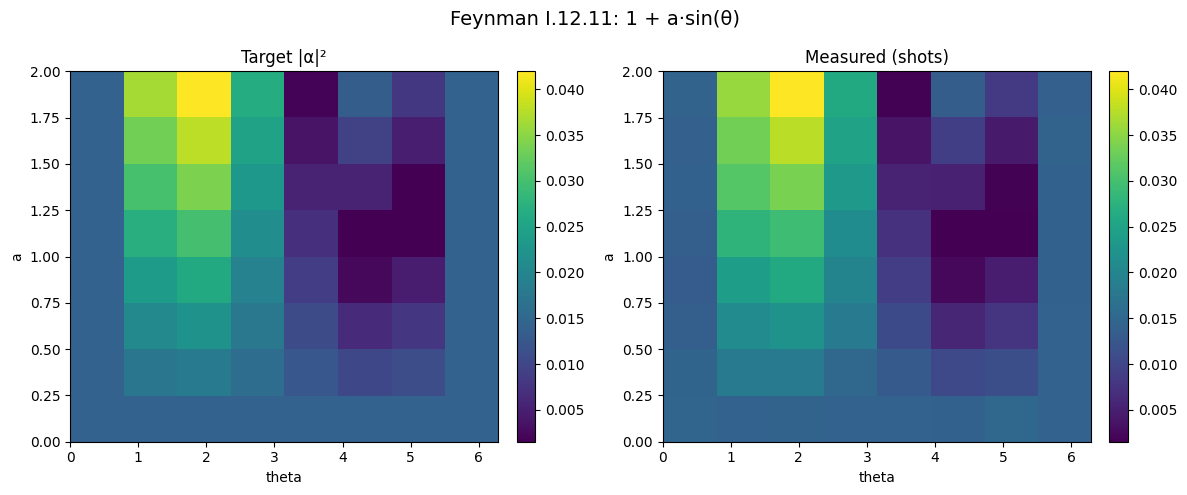

In [7]:
qfun.plot_comparison_2d(
    grid, target_prob, empirical_prob,
    title=f"Feynman {eq.eq_id}: {eq.formula}",
)

## 3  More Examples — Different Equations & Qubit Allocations

### 3.1  Gaussian Distribution (I.6.2)
$$f(\theta,\sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{\theta^2}{2\sigma^2}\right)$$

We use 4 qubits per variable → $16\times16 = 256$ points, 8 total qubits.

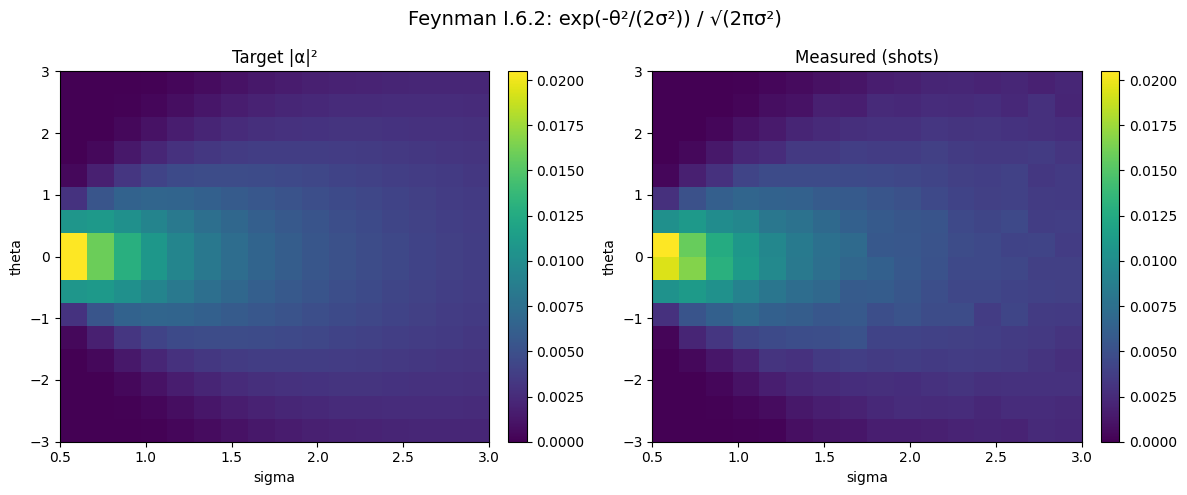

In [8]:
eq_gauss = get_equation("I.6.2")

grid_gauss = qfun.grid_nd(eq_gauss.domains, n_qubits_per_var=4)
amps_gauss = qfun.amplitudes_from_function_nd(eq_gauss.func, grid_gauss)
target_gauss = amps_gauss ** 2

counts_gauss = qfun.run_shots(amps_gauss, grid_gauss.n_qubits_total, shots=100_000)
emp_gauss = qfun.counts_to_distribution(counts_gauss, grid_gauss.n_qubits_total)

qfun.plot_comparison_2d(
    grid_gauss, target_gauss, emp_gauss,
    title=f"Feynman {eq_gauss.eq_id}: {eq_gauss.formula}",
)

### 3.2  Magnetic Moment Energy (III.10.19)
$$f(a, b) = \sqrt{1 + a^2 + b^2}$$

Comparing 3 qubits/var (8×8) vs 4 qubits/var (16×16) to show resolution improvement.

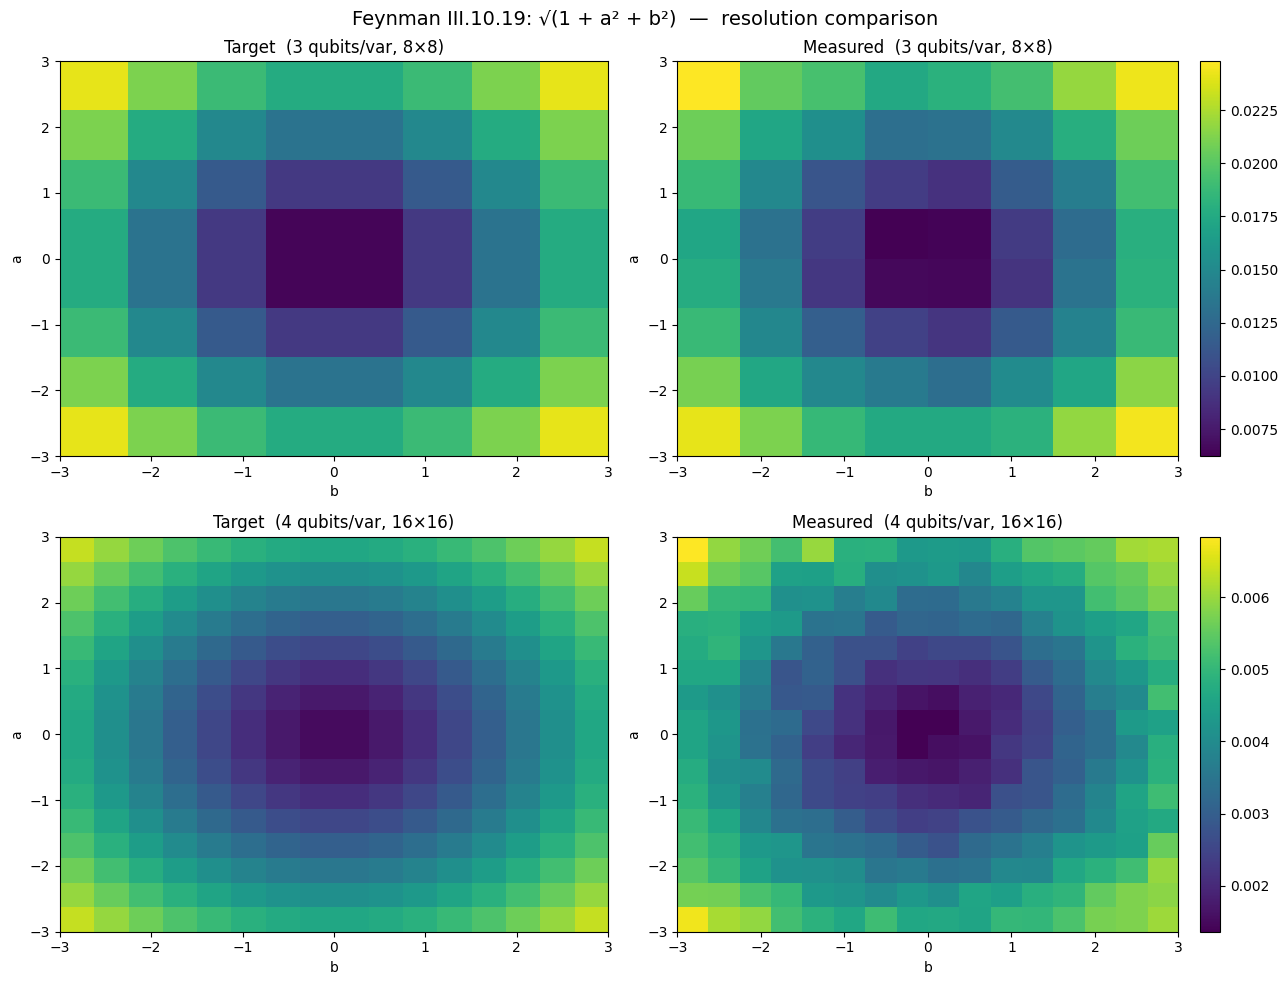

In [9]:
eq_mag = get_equation("III.10.19")

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for row, nq in enumerate([3, 4]):
    g = qfun.grid_nd(eq_mag.domains, n_qubits_per_var=nq)
    a = qfun.amplitudes_from_function_nd(eq_mag.func, g)
    t = a ** 2
    c = qfun.run_shots(a, g.n_qubits_total, shots=100_000)
    e = qfun.counts_to_distribution(c, g.n_qubits_total)

    t2d = t.reshape(g.shape)
    e2d = e.reshape(g.shape)
    vmin, vmax = min(t2d.min(), e2d.min()), max(t2d.max(), e2d.max())
    extent = [g.axes[1][0], g.axes[1][-1], g.axes[0][0], g.axes[0][-1]]

    axes[row, 0].imshow(t2d, origin="lower", aspect="auto", extent=extent,
                        vmin=vmin, vmax=vmax, cmap="viridis")
    axes[row, 0].set_title(f"Target  ({nq} qubits/var, {2**nq}×{2**nq})")
    axes[row, 0].set_xlabel(g.var_names[1])
    axes[row, 0].set_ylabel(g.var_names[0])

    im = axes[row, 1].imshow(e2d, origin="lower", aspect="auto", extent=extent,
                             vmin=vmin, vmax=vmax, cmap="viridis")
    axes[row, 1].set_title(f"Measured  ({nq} qubits/var, {2**nq}×{2**nq})")
    axes[row, 1].set_xlabel(g.var_names[1])
    axes[row, 1].set_ylabel(g.var_names[0])
    fig.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04)

fig.suptitle(f"Feynman {eq_mag.eq_id}: {eq_mag.formula}  —  resolution comparison", fontsize=14)
fig.tight_layout()
plt.show()

### 3.3  Relativistic Velocity Addition (I.16.6)
$$f(a, b) = \frac{a + b}{1 + a\cdot b}$$

Using **asymmetric** qubit allocation: 4 qubits for $a$, 3 qubits for $b$
→ $16\times8 = 128$ grid points, 7 total qubits.

Grid shape: (16, 8), total qubits: 7


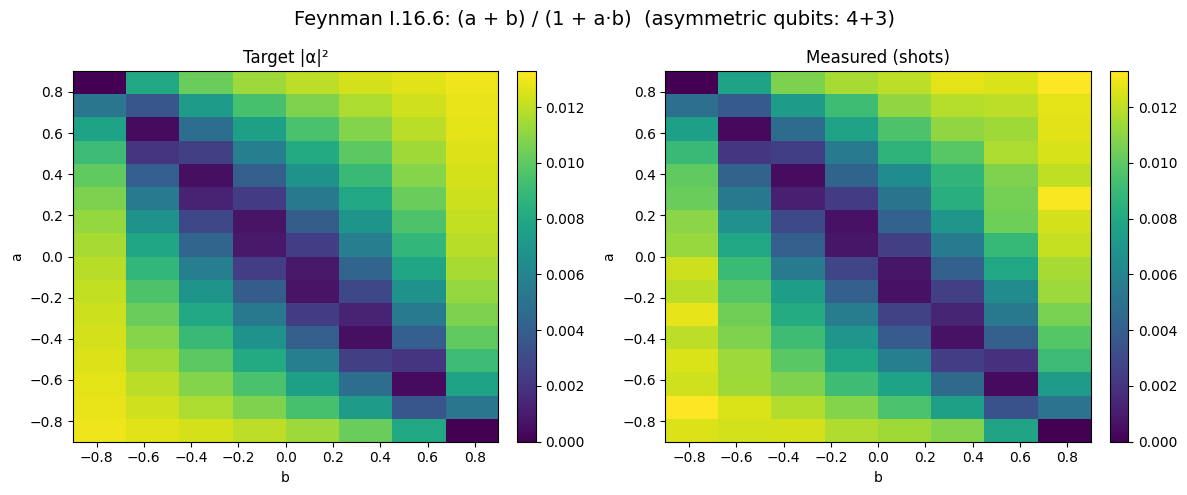

In [10]:
eq_rel = get_equation("I.16.6")

grid_rel = qfun.grid_nd(eq_rel.domains, n_qubits_per_var={"a": 4, "b": 3})
print(f"Grid shape: {grid_rel.shape}, total qubits: {grid_rel.n_qubits_total}")

amps_rel = qfun.amplitudes_from_function_nd(eq_rel.func, grid_rel)
target_rel = amps_rel ** 2
counts_rel = qfun.run_shots(amps_rel, grid_rel.n_qubits_total, shots=100_000)
emp_rel = qfun.counts_to_distribution(counts_rel, grid_rel.n_qubits_total)

qfun.plot_comparison_2d(
    grid_rel, target_rel, emp_rel,
    title=f"Feynman {eq_rel.eq_id}: {eq_rel.formula}  (asymmetric qubits: 4+3)",
)

## 4  Signed Multivariate Encoding (Mode A — Ancilla)

Some Feynman equations produce **negative values**.  For instance, **I.50.26**:
$$f(a, o) = \cos(a) + o\cos^2(a)$$
goes negative when $\cos(a) < 0$ and $o$ is small.

We use **Mode A** (ancilla qubit) to encode the sign:
- Amplitude magnitudes $\sqrt{|f(x)|}$ are encoded into data qubits.
- An extra ancilla qubit is flipped to $|1\rangle$ wherever $f(x) < 0$.
- After measurement, the ancilla bit lets us reconstruct the signed distribution.

In [11]:
eq_osc = get_equation("I.50.26")
print(f"Equation:  {eq_osc.eq_id}  —  {eq_osc.name}")
print(f"Formula:   {eq_osc.formula}")
print(f"Variables: {eq_osc.variables}, Domains: {eq_osc.domains}")

grid_osc = qfun.grid_nd(eq_osc.domains, n_qubits_per_var=3)
print(f"\nGrid: {grid_osc.shape}, total data qubits: {grid_osc.n_qubits_total}")

Equation:  I.50.26  —  Driven oscillator
Formula:   cos(a) + o·cos²(a)
Variables: ['a', 'o'], Domains: {'a': (0.0, 6.283185307179586), 'o': (0.0, 2.0)}

Grid: (8, 8), total data qubits: 6


In [12]:
cols = [grid_osc.flat_grid[:, k] for k in range(grid_osc.flat_grid.shape[1])]
y = eq_osc.func(*cols)

sign_mask = y < 0
mag = np.abs(y)
raw = np.sqrt(mag + 1e-12)
amplitudes_osc = raw / np.linalg.norm(raw)

print(f"Grid points: {len(y)}")
print(f"Negative values: {sign_mask.sum()} / {len(y)}  ({100*sign_mask.mean():.1f}%)")
print(f"Value range: [{y.min():.4f}, {y.max():.4f}]")

Grid points: 64
Negative values: 24 / 64  (37.5%)
Value range: [-0.9010, 3.0000]


In [13]:
shots = 200_000
counts_signed = qfun.run_shots_signed(
    amplitudes_osc, sign_mask, grid_osc.n_qubits_total, shots=shots,
)
sd = qfun.counts_to_signed_distribution(counts_signed, grid_osc.n_qubits_total)

target_signed = y / np.abs(y).sum()

print(f"Shots: {shots:,}")
print(f"Signed quasi-prob range: [{sd.q.min():.5f}, {sd.q.max():.5f}]")

Shots: 200,000
Signed quasi-prob range: [-0.01571, 0.05150]


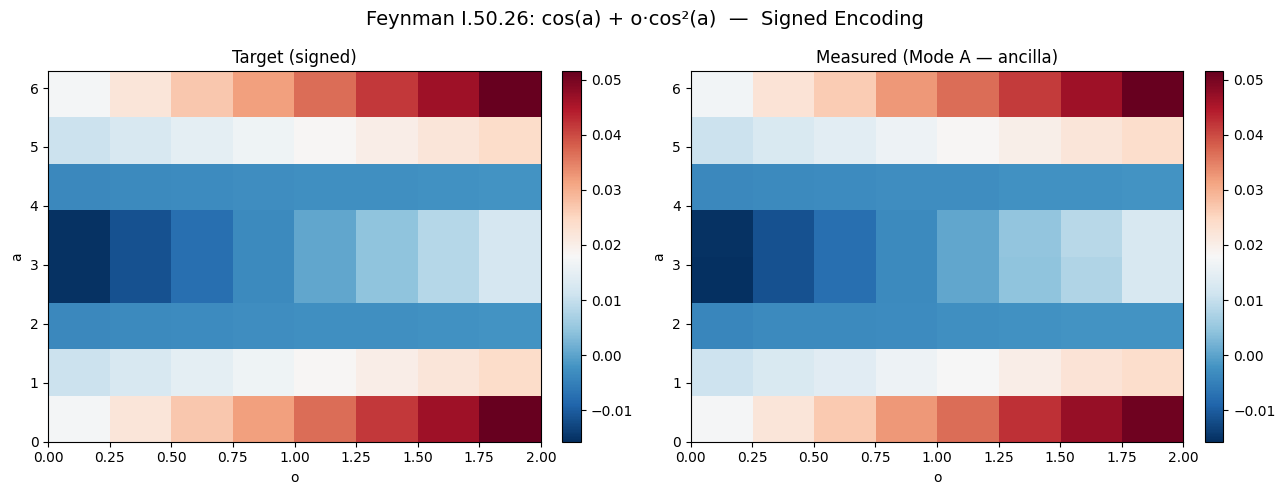

In [14]:
target_2d = target_signed.reshape(grid_osc.shape)
measured_2d = sd.q.reshape(grid_osc.shape)

vmin = min(target_2d.min(), measured_2d.min())
vmax = max(target_2d.max(), measured_2d.max())
extent = [
    grid_osc.axes[1][0], grid_osc.axes[1][-1],
    grid_osc.axes[0][0], grid_osc.axes[0][-1],
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

im1 = ax1.imshow(target_2d, origin="lower", aspect="auto", extent=extent,
                 vmin=vmin, vmax=vmax, cmap="RdBu_r")
ax1.set_title("Target (signed)")
ax1.set_xlabel(grid_osc.var_names[1])
ax1.set_ylabel(grid_osc.var_names[0])
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

im2 = ax2.imshow(measured_2d, origin="lower", aspect="auto", extent=extent,
                 vmin=vmin, vmax=vmax, cmap="RdBu_r")
ax2.set_title("Measured (Mode A — ancilla)")
ax2.set_xlabel(grid_osc.var_names[1])
ax2.set_ylabel(grid_osc.var_names[0])
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

fig.suptitle(f"Feynman {eq_osc.eq_id}: {eq_osc.formula}  —  Signed Encoding", fontsize=14)
fig.tight_layout()
plt.show()

## 5  Summary

| Feature | How |
|---|---|
| **Multivariate encoding** | `grid_nd` + `amplitudes_from_function_nd` — allocate $n_k$ qubits per variable, flatten to 1-D amplitudes |
| **Asymmetric qubit budgets** | Pass a dict `{var: n_qubits}` to give finer resolution where needed |
| **Signed functions** | Mode A (ancilla) encodes sign into an extra qubit; recovered via `counts_to_signed_distribution` |
| **Dataset** | 27 Feynman equations available via `qfun.feynman_dataset` — 1 to 6 variables each |